<a href="https://colab.research.google.com/github/lodigasatish-ai/teleconnect-ml-assignment/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TELCO CUSTOMER CHURN - EDA PROJECT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
sns.set(style="whitegrid")

In [2]:
# LOAD DATASET
print("Upload Telco Customer Churn dataset")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("\nDataset Loaded Successfully!")
print("Shape:", df.shape)

Upload Telco Customer Churn dataset


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv

Dataset Loaded Successfully!
Shape: (7043, 21)


In [3]:
# BASIC UNDERSTANDING
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

In [4]:
# DATA CLEANING
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# OUTLIER DETECTION & TREATMENT
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nOutliers handled using IQR method")


Outliers handled using IQR method


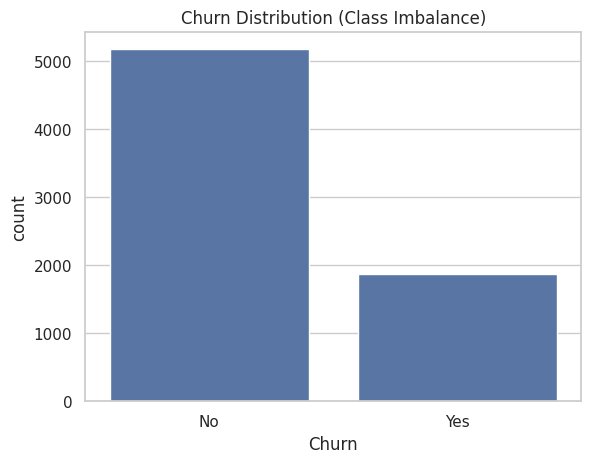


Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
# CLASS IMBALANCE ANALYSIS
plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution (Class Imbalance)")
plt.show()

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

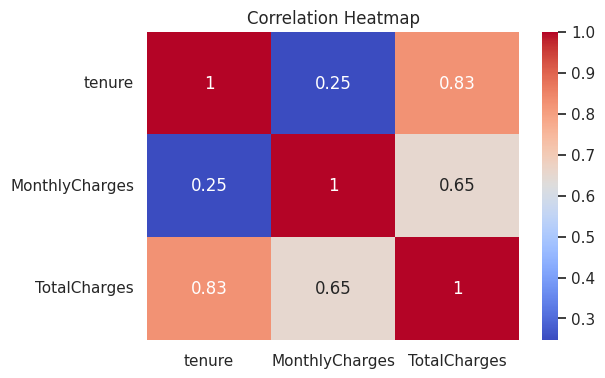

In [7]:
# CORRELATION HEATMAP
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

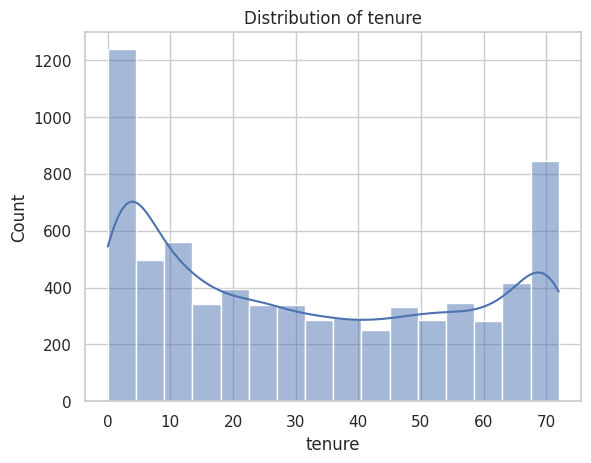

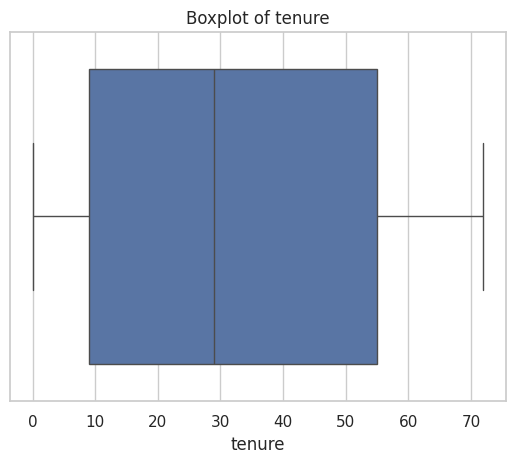

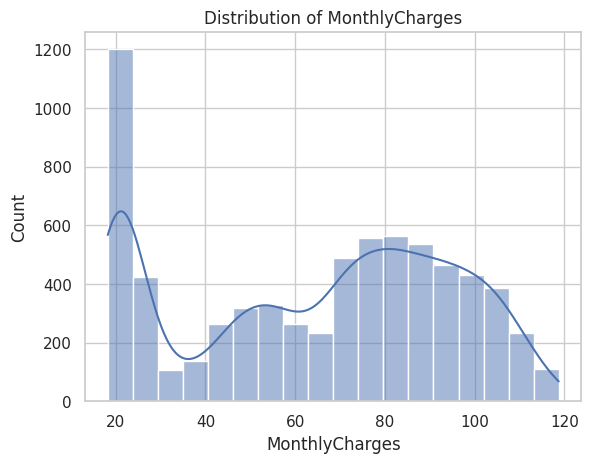

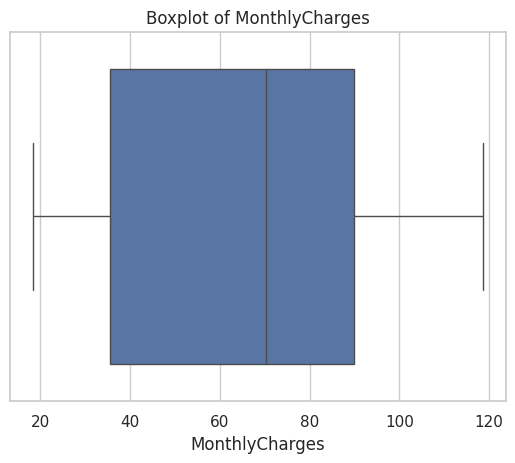

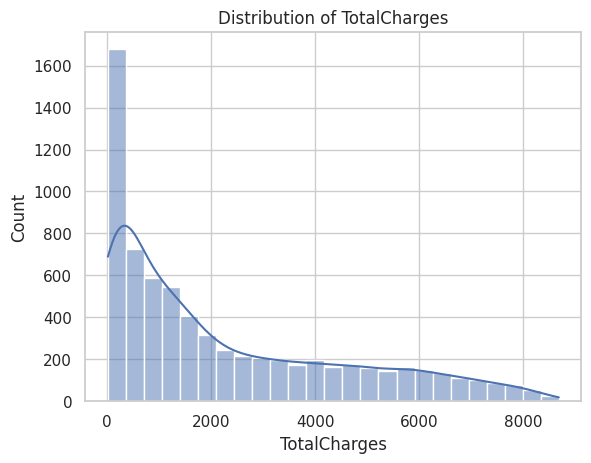

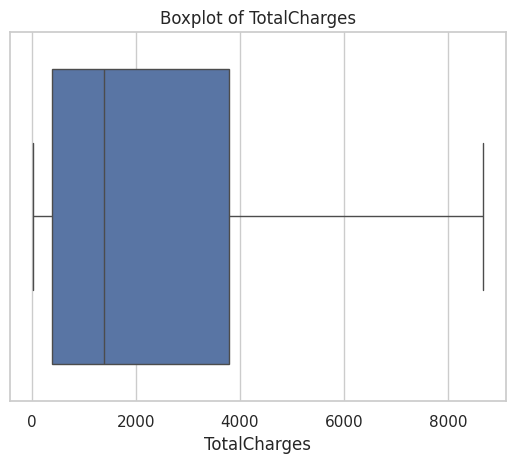

In [8]:
#FEATURE DISTRIBUTIONS
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

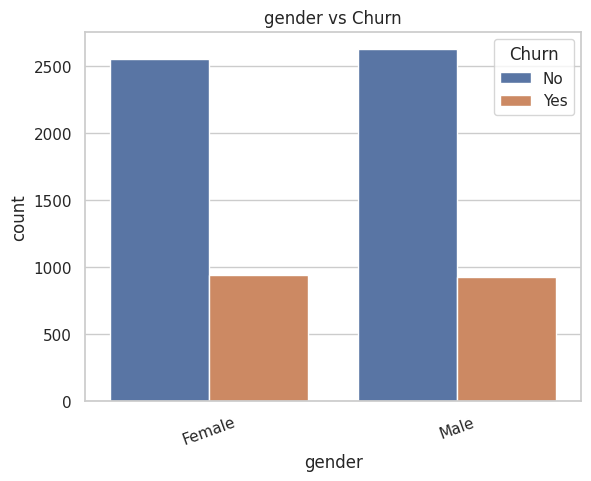

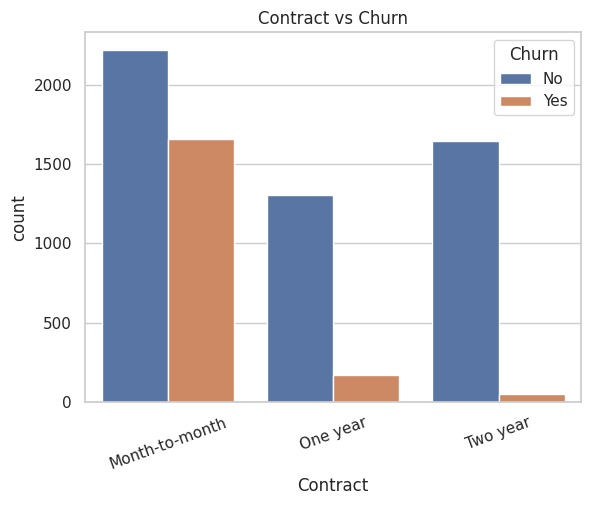

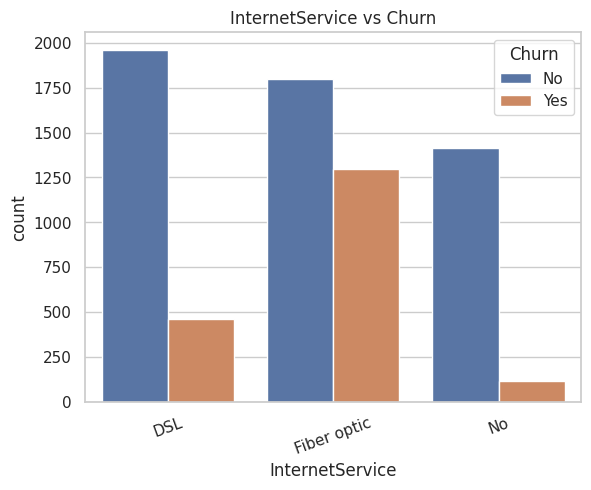

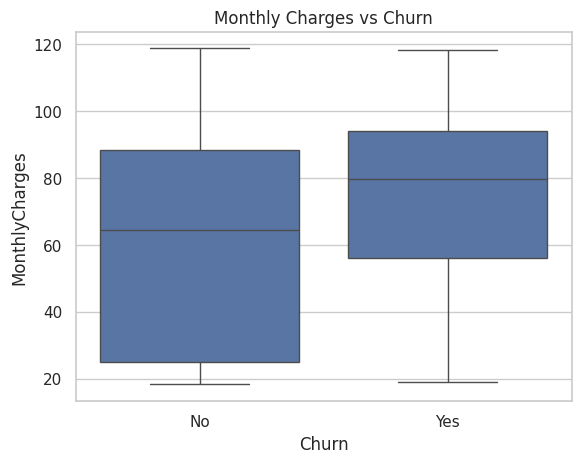

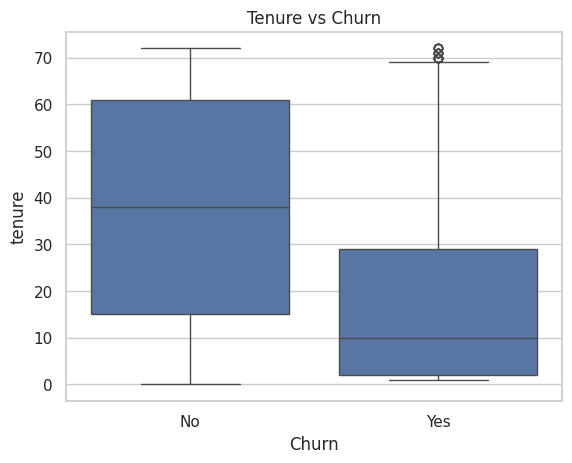

In [9]:
#BIVARIATE ANALYSIS
features = ["gender", "Contract", "InternetService"]
for col in features:
    plt.figure()
    sns.countplot(x=col, hue="Churn", data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=20)
    plt.show()

plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure()
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

In [10]:
#BUSINESS INSIGHTS
print("\n BUSINESS INSIGHTS ")
print("1. Month-to-month customers are more likely to churn.")
print("2. Higher monthly charges increase churn probability.")
print("3. New customers (low tenure) are more likely to leave.")
# FINAL RESULT
print("\nFinal Dataset Shape:", df.shape)
print("\nEDA Completed Successfully!")


 BUSINESS INSIGHTS 
1. Month-to-month customers are more likely to churn.
2. Higher monthly charges increase churn probability.
3. New customers (low tenure) are more likely to leave.

Final Dataset Shape: (7043, 21)

EDA Completed Successfully!
